In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


#Loading Dataset

In [ ]:
from zipfile import ZipFile
braintumor="/content/Final_ML.zip"
with ZipFile(braintumor,'r') as zip:
  zip.extractall()




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil

source = "/content/Final_ML.zip"   # Corrected path to the zip file
destination = "/content/drive/MyDrive/Final_ML.zip" # Corrected path in Google Drive

shutil.copy(source, destination) # Use shutil.copy for files, not shutil.copytree

'/content/drive/MyDrive/Final_ML.zip'

In [ ]:
import os
image_file=os.listdir('/content/Final_ML')
print(image_file)


['gl-0004.jpg', 'me-0014.jpg', 'me-0011.jpg', 'pi-0019.jpg', 'pi-0003.jpg', 'pi-0007.jpg', 'gl-0015.jpg', 'gl-0017.jpg', 'me-0007.jpg', 'gl-0010.jpg', 'pi-0006.jpg', 'gl-0012.jpg', 'pi-0018.jpg', 'me-0002.jpg', 'me-0020.jpg', 'me-0017.jpg', 'gl-0006.jpg', 'no-0012.jpg', 'gl-0002.jpg', 'me-0006.jpg', 'no-0010.jpg', 'me-0018.jpg', 'gl-0008.jpg', 'no-0006.jpg', 'no-0015.jpg', 'no-0008.jpg', 'no-0004.jpg', 'pi-0017.jpg', 'pi-0020.jpg', 'gl-0007.jpg', 'pi-0008.jpg', 'no-0009.jpg', 'gl-0001.jpg', 'pi-0002.jpg', 'me-0012.jpg', 'no-0019.jpg', 'pi-0004.jpg', 'me-0005.jpg', 'me-0019.jpg', 'gl-0013.jpg', 'no-0013.jpg', 'no-0011.jpg', 'no-0020.jpg', 'gl-0003.jpg', 'gl-0009.jpg', 'no-0007.jpg', 'pi-0012.jpg', 'me-0001.jpg', 'me-0004.jpg', 'me-0003.jpg', 'gl-0005.jpg', 'gl-0019.jpg', 'me-0008.jpg', 'no-0003.jpg', 'me-0016.jpg', 'pi-0010.jpg', 'pi-0016.jpg', 'no-0014.jpg', 'no-0005.jpg', 'gl-0020.jpg', 'gl-0014.jpg', 'gl-0016.jpg', 'me-0015.jpg', 'me-0013.jpg', 'pi-0009.jpg', 'no-0017.jpg', 'pi-0011.

In [ ]:
import cv2
import os
import numpy as np
images=[]
labels=[]
# Correct the base directory for image files
image_directory = '/content/Final_ML'
for file in image_file:
  if file.endswith(".jpg"):
    # Construct the correct image path
    img_path=os.path.join(image_directory,file)
    img=cv2.imread(img_path)
    if img is None:
      print(f"Warning: Could not load image {img_path}")
      continue
    # Check if image was loaded successfully before resizing
    if img is not None:
      img=cv2.resize(img,(224,224))
      img=img/255.0
      images.append(img)

      if file.startswith("gl"):
        labels.append("glioma")
      elif file.startswith("me"):
        labels.append("meningioma")
      elif file.startswith("pi"):
        labels.append("pituitary")
      elif file.startswith("no"):
        labels.append("notumor")
    else:
      print(f"Warning: Could not load image {img_path}")

# Convert to numpy arrays and print after the loop
images=np.array(images)
labels=np.array(labels)

#print size of the images
print(images.shape)
print(labels.shape)

(80, 224, 224, 3)
(80,)


ONE HOT ENCODING

In [ ]:
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Encode string labels to numerical labels
labels_encoded = le.fit_transform(labels)

# Convert numerical labels to one-hot encoded format
labels = to_categorical(labels_encoded, num_classes=len(le.classes_))
labels.shape

(80, 4)

#Train-Test split

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(images,labels,test_size=0.2,random_state=42)


#BUILD THE CNN MODEL

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D,Flatten,Dense,Dropout
model=Sequential()

#1st CONVOLUTIONAL LAYER
model.add(Conv2D(32,(3,3),activation="relu", input_shape=(224,224,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

#2nd CONVOLUTIONAL LAYER
model.add((Conv2D(64,(3,3),activation="relu")))
model.add(MaxPooling2D(pool_size=(2,2)))

#3rd CONVOLUTIONAL LAYER
model.add((Conv2D(128,(3,3),activation="relu")))
model.add(MaxPooling2D(pool_size=(2,2)))

#FLATTEN LAYER
model.add(Flatten())

#FULLY CONNECTED LAYER
model.add(Dense(128,activation="relu"))
model.add(Dropout(0.5))

#OUTPUT LAYER
model.add(Dense(4,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

#COMPILE THE MODEL

In [ ]:
from tensorflow.keras.optimizers import Adam
model.compile()
model.compile(optimizer='adam',loss= "categorical_crossentropy", metrics=['accuracy'])


#TRAIN THE MODEL

In [ ]:
history =model.fit(X_train,y_train,batch_size=32,epochs=20,validation_data=(X_test,y_test))


Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - accuracy: 0.2656 - loss: 2.2192 - val_accuracy: 0.1250 - val_loss: 2.1749
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - accuracy: 0.3906 - loss: 1.7356 - val_accuracy: 0.5000 - val_loss: 1.2233
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step - accuracy: 0.5156 - loss: 1.2080 - val_accuracy: 0.1875 - val_loss: 1.5412
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 4s/step - accuracy: 0.5000 - loss: 1.0477 - val_accuracy: 0.3750 - val_loss: 1.3117
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 5s/step - accuracy: 0.6719 - loss: 0.8858 - val_accuracy: 0.5625 - val_loss: 1.1272
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step - accuracy: 0.7031 - loss: 0.7720 - val_accuracy: 0.3125 - val_loss: 1.2482
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.7656 - loss: 0.5724 - val_accuracy: 0.3750 - val_loss: 1.2589
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step - accuracy: 0.7500 - loss: 0.5146 - val_accuracy: 0.4375 - val_loss: 1.2256
Epoch 9/20
2

#SAVE THE MODEL

In [ ]:
model.save("FinalResult_Braintumor.h5")
print("Model saved successfully")

Model saved successfully


#Evaluate the Model

In [ ]:
test_loss,test_accuracy=model.evaluate(X_test,y_test)
print("Test Accuracy:",test_accuracy)
print("Test Loss:",test_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 753ms/step - accuracy: 0.4375 - loss: 3.1675
Test Accuracy: 0.4375
Test Loss: 3.167464017868042


#Plot accuracy Graph

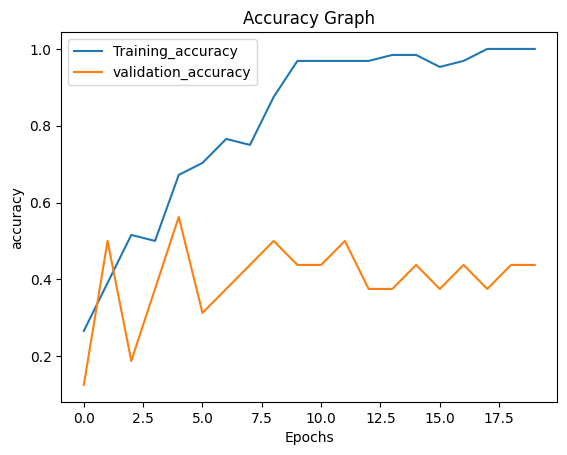

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],label="Training_accuracy")
plt.plot(history.history['val_accuracy'],label="validation_accuracy")

plt.title( "Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show()

#PLOT LOSS GRAPH

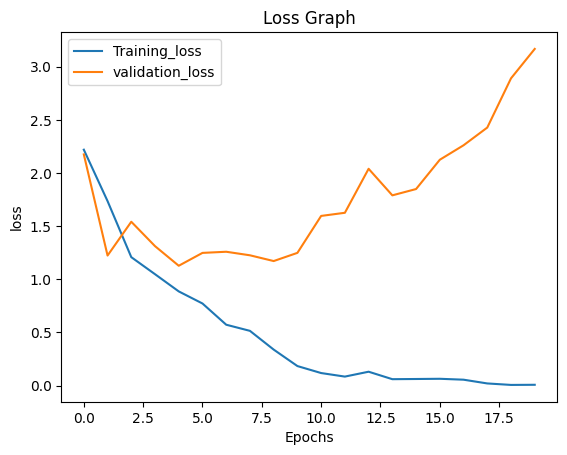

In [ ]:
plt.plot(history.history['loss'],label="Training_loss")
plt.plot(history.history['val_loss'],label="validation_loss")

plt.title( "Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("loss")
plt.legend()
plt.show()

#PREDICT TEST IMAGES
#PRECISSION, RECALL,F1SCORE

In [ ]:
import numpy as np
predictions=model.predict(X_test)
y_pred=np.argmax(predictions,axis=1)
y_true=np.argmax(y_test,axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 773ms/step


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
class_names=["glioma","meningioma","pituitary","notumor"]
print(classification_report(y_true,y_pred,target_names=class_names))
#

              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00         3
  meningioma       0.00      0.00      0.00         2
   pituitary       0.43      1.00      0.60         3
     notumor       1.00      0.50      0.67         8

    accuracy                           0.44        16
   macro avg       0.36      0.38      0.32        16
weighted avg       0.58      0.44      0.45        16



#Confusion Matrix

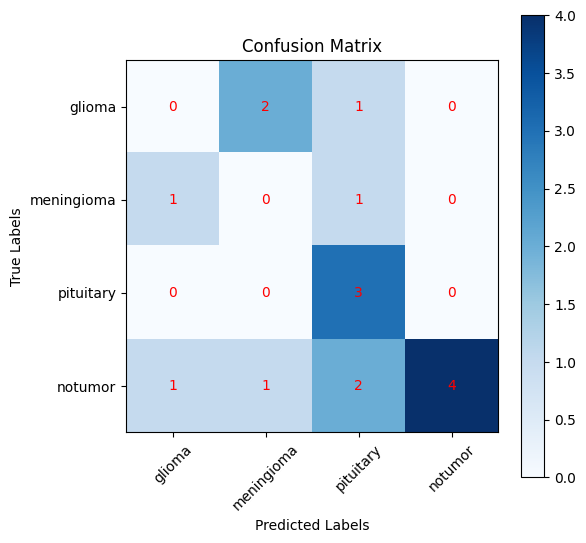

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm=confusion_matrix(y_true,y_pred)

plt.figure(figsize=(6,6))
plt.imshow(cm,cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.xticks(range(4),class_names,rotation=45)
plt.yticks(range(4),class_names)
for i in range(4):
  for j in  range(4):
    plt.text(j,i,cm[i,j], ha="center",va="center",color="red")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
model.save("/content/Drive/MyDrive/FinalResult_Braintumor.h5")
print("Model saved successfully")

Model saved successfully
